# CISE table

In [ ]:
import torch
from display_utils import evaluate_models_to_df

In [ ]:
# data_name = 'NS_heat'
# data_name = 'TE_heat'
# data_name = 'E_flow'
data_name = 'MHD'
out_channels= 5 if data_name == 'MHD' else 3

data_dict = torch.load(f'pred_all/pred_{data_name}.pt')
data_dict.keys()

dict_keys(['x', 'y_tr', 'FNO', 'CDeepONet(4096)', 'CDeepONet(2048)', 'CDeepONet(1024)', 'CDeepONet(512)', 'CDeepONet(256)', 'MDeepONet(4096)', 'MDeepONet(2048)', 'MDeepONet(1024)', 'MDeepONet(512)', 'MDeepONet(256)', 'CPodONet(4096)', 'CPodONet(2048)', 'CPodONet(1024)', 'CPodONet(512)', 'CPodONet(256)', 'MPodONet(4096)', 'MPodONet(2048)', 'MPodONet(1024)', 'MPodONet(512)', 'MPodONet(256)', 'KPodONet(4096)', 'KPodONet(2048)', 'KPodONet(1024)', 'KPodONet(512)', 'KPodONet(256)'])

In [ ]:
df = evaluate_models_to_df(data_dict)
df

Selected Best Models:
          Model_Key
2   CDeepONet(2048)
12   CPodONet(2048)
0               FNO
24    KPodONet(512)
9    MDeepONet(512)
19    MPodONet(512)


,Total Mean,Total SD,Ch0 Mean,Ch0 SD,Ch1 Mean,Ch1 SD,Ch2 Mean,Ch2 SD,Ch3 Mean,Ch3 SD,Ch4 Mean,Ch4 SD
Model,,,,,,,,,,,,
FNO,31.60,23.72,0.98,0.21,1.03,0.11,27.23,23.71,0.90,0.65,1.47,0.78
CDeepONet,815.13,12.61,0.50,0.13,0.67,0.06,813.76,12.56,0.05,0.05,0.15,0.18
MDeepONet,34.17,21.73,1.10,0.06,1.38,0.09,31.00,21.84,0.22,0.22,0.46,0.34
CPodONet,25.15,23.59,0.26,0.18,0.19,0.19,24.59,23.32,0.02,0.07,0.08,0.24
MPodONet,25.34,23.74,0.26,0.17,0.19,0.19,24.82,23.47,0.01,0.03,0.05,0.13
KPodONet,24.41,22.71,0.25,0.18,0.18,0.18,23.58,22.46,0.13,0.33,0.27,0.62


In [ ]:
# print(df.to_latex())

# CISE plot

In [ ]:
import torch
from display_utils import ms_df, plot_model_performance, plot_multiline_performance

In [41]:
# data_name = 'NS_heat'
# data_name = 'TE_heat'
# data_name = 'E_flow'
data_name = 'MHD'
out_channels= 5 if data_name == 'MHD' else 3

data_dict = torch.load(f'pred_all/pred_{data_name}.pt')
data_dict.keys()

dict_keys(['x', 'y_tr', 'FNO', 'CDeepONet(4096)', 'CDeepONet(2048)', 'CDeepONet(1024)', 'CDeepONet(512)', 'CDeepONet(256)', 'MDeepONet(4096)', 'MDeepONet(2048)', 'MDeepONet(1024)', 'MDeepONet(512)', 'MDeepONet(256)', 'CPodONet(4096)', 'CPodONet(2048)', 'CPodONet(1024)', 'CPodONet(512)', 'CPodONet(256)', 'MPodONet(4096)', 'MPodONet(2048)', 'MPodONet(1024)', 'MPodONet(512)', 'MPodONet(256)'])

In [42]:
df = ms_df(data_dict)
# df

In [33]:
var_names = {
    'TE_heat':[r'Re($E$)',r'Im($E$)', r'$T$'],
    'NS_heat':[r'$u_u$', r'$u_v$', r'$T$'],
    'E_flow': [r'$V$', r'$u_u$',r'$u_v$'],
    'MHD': [r'$J_x$',r'$J_y$',r'$J_z$', r'$u_u$',r'$u_v$'], 
}

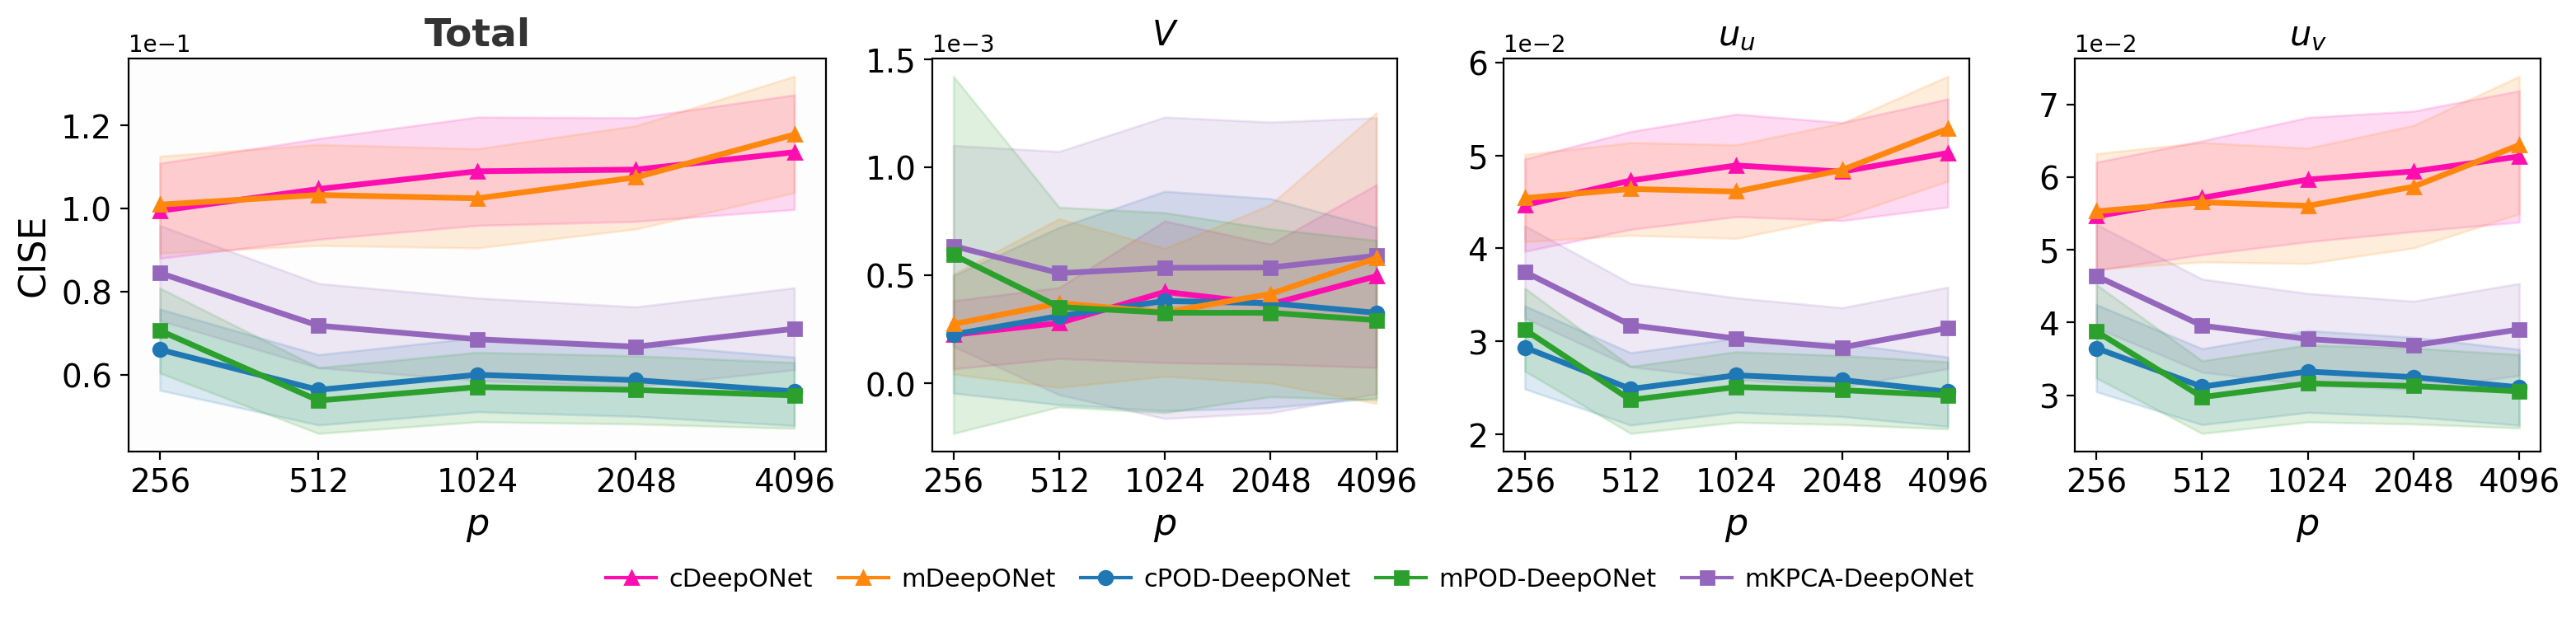

In [ ]:
plot_model_performance(df, scale=1, var_names=var_names[data_name])

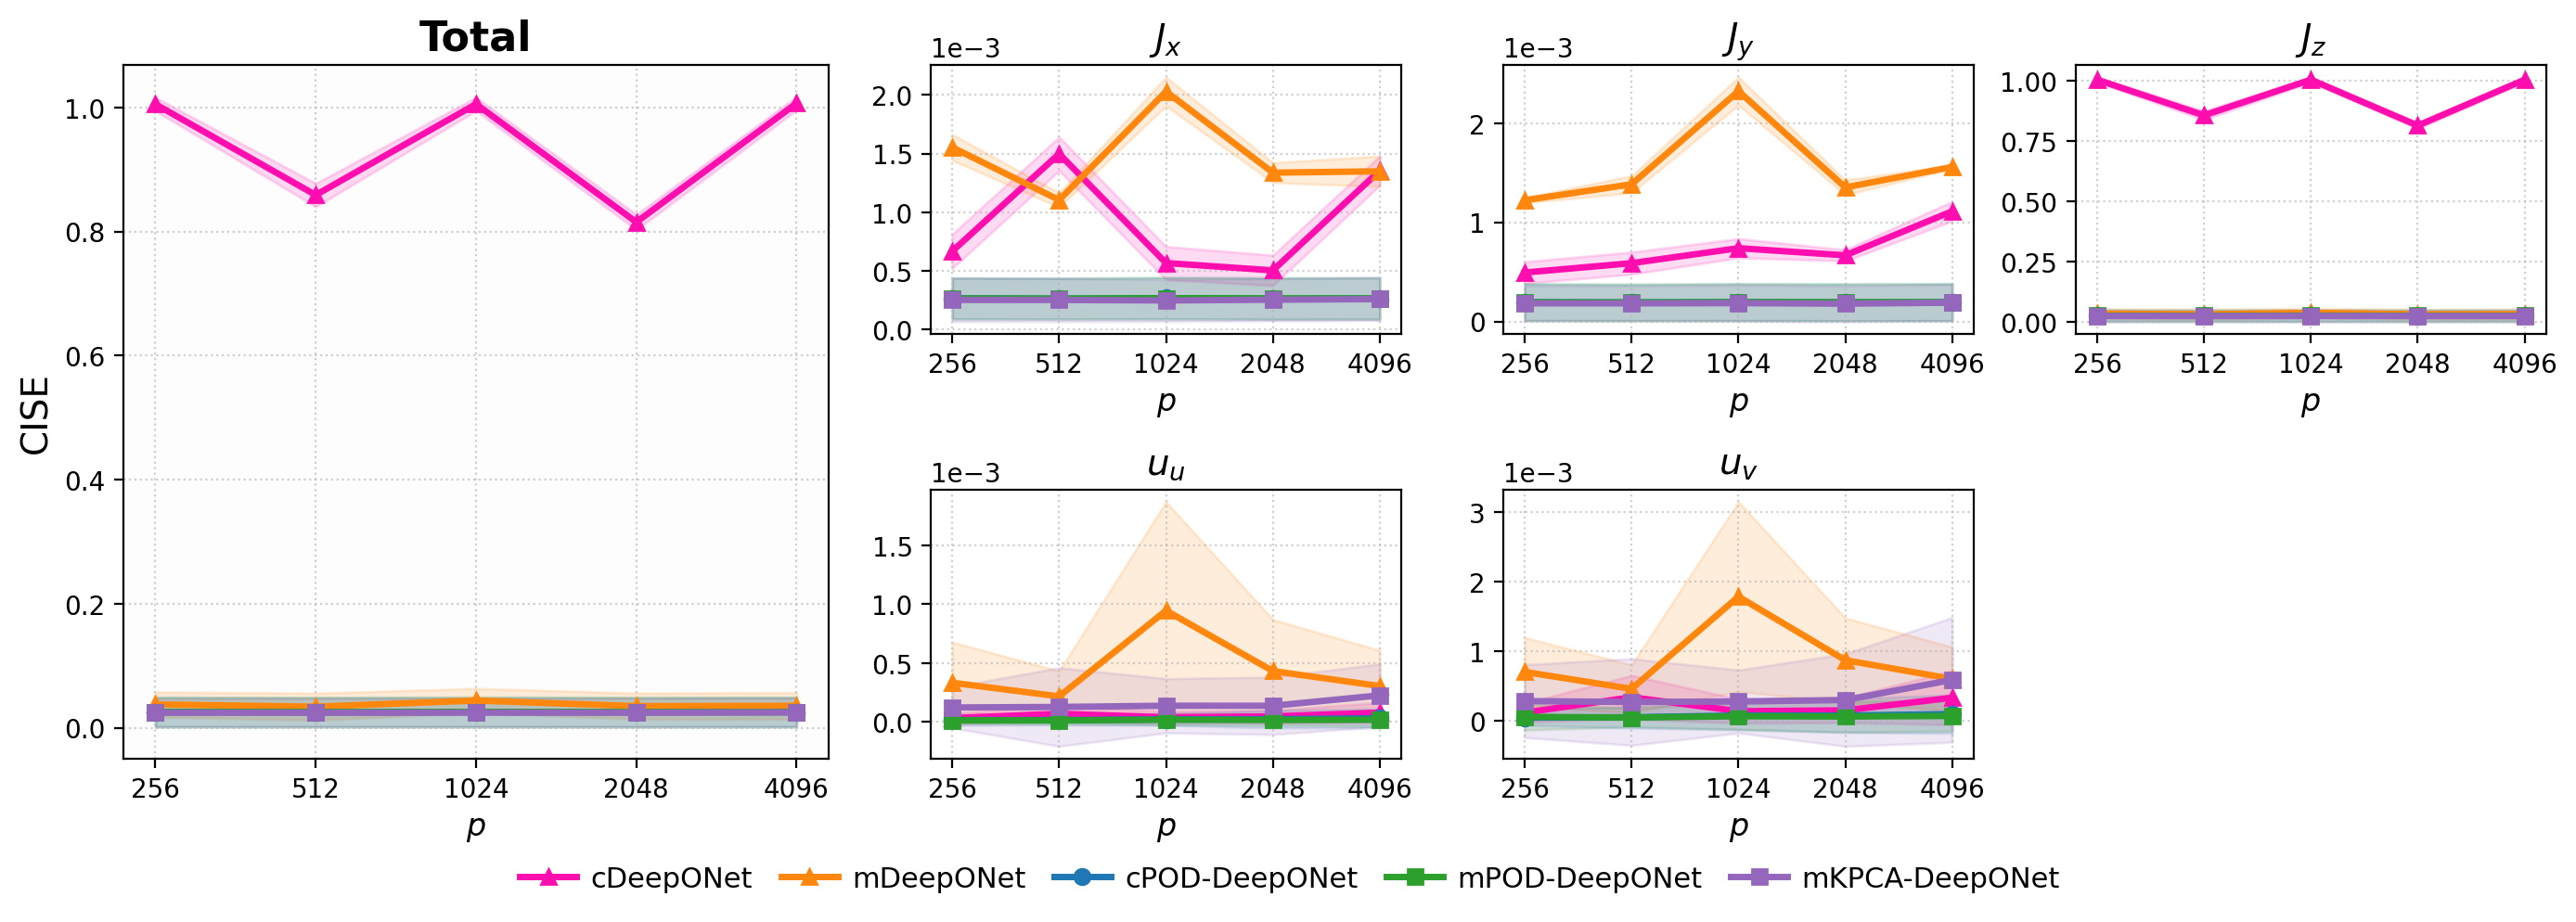

In [ ]:
plot_multiline_performance(df, var_names=var_names[data_name])

# Time and Parameter table

In [15]:
import torch
import pandas as pd
from neuralop.utils import count_model_params
all_results = []
out_channels=3
data_name = 'NS_heat'
mean_time = lambda x: sum(x)/len(x)

In [2]:
from neuralop.models import FNO
model = FNO(
        n_modes=(12, 12),
        in_channels=1,
        out_channels=out_channels,
        hidden_channels=32,
        projection_channel_ratio=2)
n_params = count_model_params(model)
ckpt = torch.load(f'logs/{data_name}/FNO_nop_epoch=500.pt', weights_only=False)
ckpt_row = {
    'Model': 'FNO', 
    'p':'',
    'n_param': n_params,
    'train_time':mean_time(ckpt['logs']['train_time']),
    'test_time':mean_time(ckpt['logs']['test_time'])
}
all_results.append(ckpt_row)

In [16]:
from models.DeepONet import DeepONet
for p in [4096,2048,1024,512,256]:
    model = DeepONet(p=p)
    n_params = count_model_params(model)
    ckpt = torch.load(f'logs/{data_name}/MDeepONet_p{p}_epoch=500.pt', weights_only=False)
    ckpt_row = {
        'Model': 'MDeepONet', 
        'p':p,
        'n_param': n_params,
        'train_time':mean_time(ckpt['logs']['train_time']),
        'test_time':mean_time(ckpt['logs']['test_time'])
    }
    all_results.append(ckpt_row)

In [17]:
from models.DeepONet import MultiTrunkDeepONet
for p in [4096,2048,1024,512,256]:
    model = MultiTrunkDeepONet(
        p=p, out_channels=out_channels)
    n_params = count_model_params(model)
    ckpt = torch.load(f'logs/{data_name}/MDeepONet_p{p}_epoch=500.pt')
    ckpt_row = {
        'Model': 'CDeepONet', 
        'p':p,
        'n_param': n_params,
        'train_time':mean_time(ckpt['logs']['train_time']),
        'test_time':mean_time(ckpt['logs']['test_time'])
    }
    all_results.append(ckpt_row)

In [12]:
from models.MFPCA import ChannelPodONet
for p in [8192,4096,2048,1024,512,256]:
    model = ChannelPodONet(
        p=p, out_channels=out_channels)
    n_params = count_model_params(model)
    ckpt = torch.load(f'logs/{data_name}/CPodONet_p{p}_epoch=500.pt')
    ckpt_row = {
        'Model': 'CPOD-DeepONet', 
        'p':p,
        'n_param': n_params,
        'train_time':mean_time(ckpt['logs']['train_time']),
        'test_time':mean_time(ckpt['logs']['test_time'])
    }
    all_results.append(ckpt_row)

In [ ]:
from models.MFPCA import MPodONet
for p in [4096,2048,1024,512,256]:
    model = MPodONet(
        p=p, out_channels=out_channels)
    n_params = count_model_params(model)
    ckpt = torch.load(f'logs/{data_name}/MPodONet_p{p}_epoch=500.pt')
    ckpt_row = {
        'Model': 'MPOD-DeepONet', 
        'p':p,
        'n_param': n_params,
        'train_time':mean_time(ckpt['logs']['train_time']),
        'test_time':mean_time(ckpt['logs']['test_time'])
    }
    all_results.append(ckpt_row)

In [ ]:
import glob
import re
from models.MKPCA import MKPodONet

for p in [4096, 2048, 1024, 512, 256]:
    # Use glob to find the specific file containing the best gamma value
    search_pattern = f'logs/{data_name}/KPodONet_p{p}g*_epoch=500.pt'
    found_files = glob.glob(search_pattern)
    
    if not found_files:
        print(f"⚠️ Warning: No checkpoint found for p={p}")
        continue
        
    ckpt_path = found_files[0]
    
    # Extract the gamma value from the filename
    gamma_match = re.search(r'g([0-9.e-]+)_epoch', ckpt_path)
    gamma = float(gamma_match.group(1)) if gamma_match else 1e-5
    
    # Initialize model to count parameters accurately based on gamma
    model = MKPodONet(
        p=p, gamma=gamma, out_channels=out_channels
    )
    n_params = count_model_params(model)
    
    # Load checkpoint to get logs for timing (load to CPU to save GPU memory)
    ckpt = torch.load(ckpt_path, map_location='cpu')
    
    ckpt_row = {
        'Model': 'KPodONet', 
        'p': p,
        'n_param': n_params,
        'train_time': mean_time(ckpt['logs']['train_time']),
        'test_time': mean_time(ckpt['logs']['test_time'])
    }
    all_results.append(ckpt_row)


In [ ]:
df = pd.DataFrame(all_results)
df['n_param'] = (df['n_param']).map(lambda x: f"{x/1e6:.1f}{{M}}")
df['train_time'] = df['train_time'].map(lambda x: f"{x:.2f}")
df['test_time'] = df['test_time'].map(lambda x: f"{x:.2f}")
df['Model'] = df['Model'].mask(df['Model'].duplicated(), '')
df = df.set_index('Model')
df

,p,n_param,train_time,test_time
Model,,,,
FNO,,0.7{M},12.72,0.51
MDeepONet,4096,28.9{M},10.02,0.35
,2048,19.5{M},6.52,0.23
,1024,14.8{M},4.77,0.17
,512,12.4{M},3.92,0.14
,256,11.2{M},3.49,0.12
CDeepONet,4096,29.2{M},10.02,0.35
,2048,19.7{M},6.52,0.23
,1024,15.0{M},4.77,0.17
